In [5]:
import os
import pandas as pd 
import datetime
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
%pip install keras tensorflow plotly seaborn pandas numpy matplotlib scikit-learn scipy
%pip install nbformat>=4.2.0


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
data=pd.read_csv('C:/Users/USER/OneDrive/Desktop/ML and AI/Projects/trade_data.csv')
print(data)

    CountryISO3  year TradeFlow  NTM Coverage ratio  NTM Frequency ratio  \
0           AFG  2012    Export           69.919167            11.377820   
1           AFG  2012    Import           22.738760            13.304281   
2           ARE  2015    Export           39.365887            51.033099   
3           ARE  2015    Import           73.059218            60.186625   
4           ARG  2017    Export           76.158763            28.674102   
..          ...   ...       ...                 ...                  ...   
147         VEN  2016    Import           10.093981             3.454307   
148         VNM  2015    Export           46.529703            21.807554   
149         VNM  2015    Import           37.986131            47.035176   
150         WLD    75    Export           27.314458            21.883389   
151         WLD    75    Import           71.982103            43.042438   

     Traded products - total  NTM affected product - count   Total Trade  \
0          

In [ ]:
import pandas as pd
import plotly.express as px
results = data[['CountryISO3', 'Total Trade']].copy()
results = results.rename(columns={'Total Trade': 'true_Total Trade'})

results['predicted_Total Trade'] = results['true_Total Trade'].shift(1)
results['predicted_Total Trade'].fillna(method='bfill', inplace=True)

results = results.sort_values('CountryISO3')

df_long = results.melt(id_vars='CountryISO3', 
                       value_vars=['true_Total Trade', 'predicted_Total Trade'],
                       var_name='type', 
                       value_name='Total Trade')

color_map = {'true_Total Trade': 'blue', 'predicted_Total Trade': 'green'}

fig = px.line(df_long, 
              x='CountryISO3', 
              y='Total Trade', 
              color='type',
              color_discrete_map=color_map,
              labels={'CountryISO3': 'Country ISO Code', 'Total Trade': 'Total Trade Amount', 'type': 'Data Type'},
              title='Actual (blue) vs Predicted (green) Total Trade by Country')
fig.update_xaxes(type='category', rangeslider_visible=True)
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_29068\781595048.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  results['predicted_Total Trade'].fillna(method='bfill', inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_29068\781595048.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  results['predicted_Total Trade'].fillna(method='bfill', inplace=True)


In [8]:
# visualization of world wide total trade
fig = px.choropleth(data,
                    locations='CountryISO3', 
                    color='Total Trade',
                    hover_name='CountryISO3',
                    color_continuous_scale='Viridis',
                    title='Geographical Distribution of Total Trade Worldwide')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

In [9]:
fig = px.bar(data, 
             x='CountryISO3', 
             y='Total Trade',
             color='Total Trade',
             title='Total Trade of WorldWide Countries',
             labels={'CountryISO3': 'Country ISO Code', 'Total Trade': 'Total Trade Amount'},
             color_continuous_scale='Viridis')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

In [10]:
# Analysis of Southeast Asian countries
data = pd.read_csv('C:/Users/USER/OneDrive/Desktop/ML and AI/Projects/trade_data.csv')
asean_iso3 = ['BRN', 'KHM', 'IDN', 'LAO', 'MYS', 'MMR', 'PHL', 'SGP', 'THA', 'TLS', 'VNM']
asean_data = data[data['CountryISO3'].isin(asean_iso3)]
print(asean_data)

    CountryISO3  year TradeFlow  NTM Coverage ratio  NTM Frequency ratio  \
24          BRN  2015    Export           38.177110            15.194611   
25          BRN  2015    Import           44.468359            25.179191   
64          IDN  2015    Export           59.753107            33.665511   
65          IDN  2015    Import           68.952902            56.334340   
74          KHM  2015    Export           93.551712            71.637249   
75          KHM  2015    Import           82.758615            72.854992   
88          MMR  2015    Export           69.970074            29.750890   
89          MMR  2015    Import           60.237527            38.438645   
92          MYS  2015    Export           14.884461            21.381170   
93          MYS  2015    Import           54.955508            36.603106   
112         PHL  2015    Export           71.604784            41.162386   
113         PHL  2015    Import           84.759469            71.859296   
126         

In [11]:
# graphical representation of ASEAN countries' trade data
fig = px.bar(asean_data, 
             x='CountryISO3', 
             y='Total Trade',
             color='Total Trade',
             title='Total Trade of ASEAN Countries',
             labels={'CountryISO3': 'Country ISO Code', 'Total Trade': 'Total Trade Amount'},
             color_continuous_scale='Viridis')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

In [12]:
# Visualization of all the dataframe data for Southeast Asian Countries geographically
fig = px.choropleth(asean_data, 
                    locations='CountryISO3', 
                    color='Total Trade',
                    hover_name='CountryISO3',
                    color_continuous_scale='Plasma',
                    title='Geographical Distribution of Total Trade in ASEAN Countries')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

In [13]:
sea=pd.read_csv('c:/Users/USER/OneDrive/Desktop/ML and AI/Projects/asean_tariff_tax_analysis.csv')
print(sea)

   CountryISO3  NTM Coverage ratio   Total Trade  Traiff value   Tariff rate
0          BRN           38.177110  7.813469e+06   2.982956e+06    38.177110
1          BRN           44.468359  3.651138e+06   1.623601e+06    44.468359
2          IDN           59.753107  1.623171e+08   9.698954e+07    59.753107
3          IDN           68.952902  1.569427e+08   1.082165e+08    68.952902
4          KHM           93.551712  9.227339e+06   8.632334e+06    93.551712
5          KHM           82.758615  1.163339e+07   9.627635e+06    82.758615
6          MMR           69.970074  1.332752e+07   9.325277e+06    69.970074
7          MMR           60.237527  1.717816e+07   1.034770e+07    60.237527
8          MYS           14.884461  2.115214e+08   3.148382e+07    14.884461
9          MYS           54.955508  1.885249e+08   1.036048e+08    54.955508
10         PHL           71.604784  1.585134e+08   1.135032e+08    71.604784
11         PHL           84.759469  2.069511e+08   1.754106e+08    84.759469

In [14]:
# Visualization of SEA data geographically
fig = px.choropleth(sea,
                    locations='CountryISO3', 
                    color='Traiff value ',
                    hover_name='CountryISO3',
                    color_continuous_scale='Cividis',
                    title='Geographical Distribution of Tariff value in Southeast Asia')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()
fig = px.choropleth(sea,
                    locations='CountryISO3', 
                    color='Tariff rate',
                    hover_name='CountryISO3',
                    color_continuous_scale='Cividis',
                    title='Geographical Distribution of Tariff rate in Southeast Asia')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

In [ ]:
#  top 15 Southeast Asian Countries Firms tariff tax analysis
sea_firms=pd.read_csv('c:/Users/USER/OneDrive/Desktop/ML and AI/Projects/yes - yes.csv')
print(sea_firms)

    Rank                    Bank Name      Country  \
0      1                     DBS Bank    Singapore   
1      2                    OCBC Bank    Singapore   
2      3   United Overseas Bank (UOB)    Singapore   
3      4                      Maybank     Malaysia   
4      5                   CIMB Group     Malaysia   
5      6                 Bangkok Bank     Thailand   
6      7                 Kasikornbank     Thailand   
7      8                 Bank Mandiri    Indonesia   
8      9  Bank Rakyat Indonesia (BRI)    Indonesia   
9     10           Public Bank Berhad     Malaysia   
10    11              Krung Thai Bank     Thailand   
11    12         Siam Commercial Bank     Thailand   
12    13                         BIDV      Vietnam   
13    14      Bank Central Asia (BCA)    Indonesia   
14    15                  BDO Unibank  Philippines   

   Total Assets (Est. USD Billion)  
0                           $554.5  
1                           $417.5  
2                       

In [ ]:
# geographical representation of top 15 Southeast Asian Countries Firms tariff tax analysis
# convert assets column to numeric (remove $ and commas) for proper coloring
sea_firms['Total Assets (Est. USD Billion)'] = sea_firms['Total Assets (Est. USD Billion)'].replace({'\$':'', ',':''}, regex=True).astype(float)

fig = px.choropleth(sea_firms,
                    locations='Country',                     
                    color='Total Assets (Est. USD Billion)',
                    hover_name='Bank Name',
                    locationmode='country names',           
                    color_continuous_scale='Cividis',
                    title='Geographical Distribution of Total Assets in Southeast Asia')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\USER\AppData\Local\Temp\ipykernel_13536\1502800065.py:3: SyntaxWarning: invalid escape sequence '\$'
  sea_firms['Total Assets (Est. USD Billion)'] = sea_firms['Total Assets (Est. USD Billion)'].replace({'\$':'', ',':''}, regex=True).astype(float)
C:\Users\USER\AppData\Local\Temp\ipykernel_13536\1502800065.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(sea_firms,


In [ ]:
# Data for top 15 SE Asian Banks (Total Assets in USD Billion)
# Sources: Wikipedia (Forbes 2022) and TABInsights 2024/2025 estimates
data = {
    'Bank Name': [
        'DBS Bank', 'OCBC Bank', 'United Overseas Bank', 'Maybank', 'CIMB',
        'Bangkok Bank', 'Kasikornbank', 'Bank Mandiri', 'Bank Rakyat Indonesia', 'Public Bank Berhad',
        'Krung Thai Bank', 'Siam Commercial Bank', 'Bank Central Asia', 'BIDV', 'BDO Unibank'
    ],
    'Total Assets (Est. USD Billion)': [
        606.1, 458.0, 394.0, 213.2, 149.3, 
        130.7, 124.3, 121.1, 117.7, 111.1, 
        107.7, 101.4, 87.7, 77.3, 69.5
    ]
}

sea_firms = pd.DataFrame(data)

# Apply the user's logic
results = sea_firms[['Bank Name', 'Total Assets (Est. USD Billion)']].copy()
results = results.rename(columns={'Total Assets (Est. USD Billion)': 'true_Total Assets'})

# Prediction logic as requested: shift(1) and backfill the first NaN
results['predicted_Total Assets'] = results['true_Total Assets'].shift(1)
results['predicted_Total Assets'] = results['predicted_Total Assets'].bfill()

# Save the final dataframe representation to CSV
results.to_csv('sea_banks_actual_vs_predicted.csv', index=False)

plt.tight_layout()
plt.savefig('actual_vs_predicted_assets.png')

print(results)

                Bank Name  true_Total Assets  predicted_Total Assets
0                DBS Bank              606.1                   606.1
1               OCBC Bank              458.0                   606.1
2    United Overseas Bank              394.0                   458.0
3                 Maybank              213.2                   394.0
4                    CIMB              149.3                   213.2
5            Bangkok Bank              130.7                   149.3
6            Kasikornbank              124.3                   130.7
7            Bank Mandiri              121.1                   124.3
8   Bank Rakyat Indonesia              117.7                   121.1
9      Public Bank Berhad              111.1                   117.7
10        Krung Thai Bank              107.7                   111.1
11   Siam Commercial Bank              101.4                   107.7
12      Bank Central Asia               87.7                   101.4
13                   BIDV         

<Figure size 640x480 with 0 Axes>

In [ ]:
# create actual and predicted comparison line plot for tariff rate vs Total Trade
results = sea[['CountryISO3', 'Tariff rate']].copy()
results = results.rename(columns={'Tariff rate': 'true_Tariff rate'})
results['predicted_Tariff rate'] = results['true_Tariff rate'].shift(1)
results['predicted_Tariff rate'].fillna(method='bfill', inplace=True)
results = results.sort_values('CountryISO3')
df_long = results.melt(id_vars='CountryISO3', 
                       value_vars=['true_Tariff rate', 'predicted_Tariff rate'],
                       var_name='type', 
                       value_name='Tariff rate')
color_map = {'true_Tariff rate': 'blue', 'predicted_Tariff rate': 'green'}
fig = px.line(df_long, 
              x='CountryISO3', 
              y='Tariff rate', 
              color='type',
              color_discrete_map=color_map,
              labels={'CountryISO3': 'Country ISO Code', 'Tariff rate': 'Tariff Rate', 'type': 'Data Type'},
              title='Actual (blue) vs Predicted (green) Tariff Rate by Country')
fig.update_xaxes(type='category', rangeslider_visible=True)
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_13536\3478225186.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\USER\AppData\Local\Temp\ipykernel_13536\3478225186.py:5: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [ ]:
# Bar chart representation of top 15 Southeast Asian Countries Firms actual vs predicted Total Assets
results = sea_firms[['Bank Name', 'Total Assets (Est. USD Billion)']].copy()
results = results.rename(columns={'Total Assets (Est. USD Billion)': 'true_Total Assets'})
results['predicted_Total Assets'] = results['true_Total Assets'].shift(1)
results['predicted_Total Assets'].fillna(method='bfill', inplace=True)
df_long = results.melt(id_vars='Bank Name', 
                       value_vars=['true_Total Assets', 'predicted_Total Assets'],
                       var_name='type', 
                       value_name='Total Assets (Est. USD Billion)')
color_map = {'true_Total Assets': 'blue', 'predicted_Total Assets': 'green'}
fig = px.bar(df_long,
                x='Bank Name', 
                y='Total Assets (Est. USD Billion)', 
                color='type',
                color_discrete_map=color_map,
                labels={'Bank Name': 'Bank Name', 'Total Assets (Est. USD Billion)': 'Total Assets (Est. USD Billion)', 'type': 'Data Type'},
                title='Actual (blue) vs Predicted (green) Total Assets by Bank')
fig.update_layout(height=600, margin=dict(t=50, b=50, l=50, r=50))
fig.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_13536\788136398.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\USER\AppData\Local\Temp\ipykernel_13536\788136398.py:5: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



Test R^2 Score: -0.6040
Mean Squared Error: 954.1975


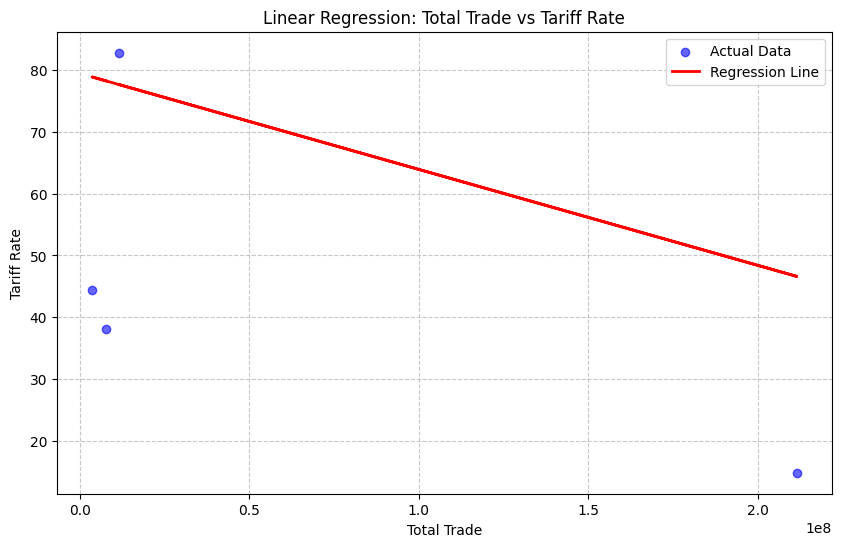

In [ ]:
# Linear Regression Model: Predicting Tariff rate based on Total Trade in Southeast Asia
sea_clean = sea[['Total Trade', 'Tariff rate']].dropna()
X = sea_clean[['Total Trade']]
y = sea_clean['Tariff rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Test R^2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data', alpha=0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression: Total Trade vs Tariff Rate')
plt.xlabel('Total Trade')
plt.ylabel('Tariff Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()